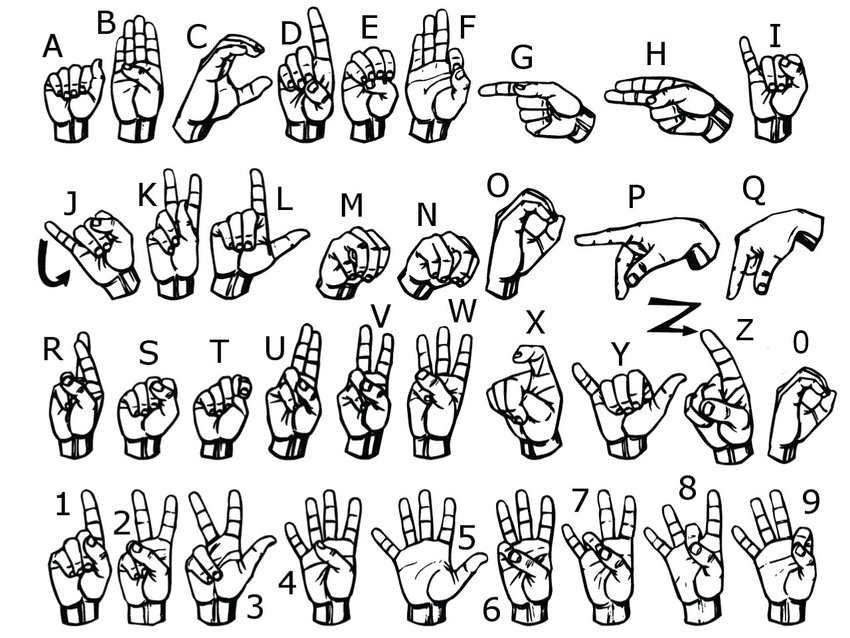

# collect images with different hand positions

In [4]:

import cv2
import os
import time

os.chdir(r"D:\proj-python\Images_Vision")

data_dir = "American-Sign-Language"
os.makedirs(data_dir, exist_ok=True)

num_classes = 3
dataset_size = 100

cap = cv2.VideoCapture(1)

if not cap.isOpened():
    print("Error: Camera could not be opened")
    exit()

running = True

for i in range(num_classes):
    class_dir = os.path.join(data_dir, str(i))
    os.makedirs(class_dir, exist_ok=True)

    print("Collecting data for class {}".format(i))

    while running:
        ret, frame = cap.read()

        if not ret:
            print("Error: Failed to capture frame")
            running = False
            break

        cv2.putText(frame, "Class {}: Press S to start | Q to quit".format(i), (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.imshow("frame", frame)

        key = cv2.waitKey(1) & 0xFF

        if key == ord("s"):
            break
        elif key == ord("q"):
            running = False
            break

    if not running:
        break

    counter = 0

    while counter < dataset_size and running:
        ret, frame = cap.read()

        if not ret:
            print("Error: Failed to capture frame")
            running = False
            break

        cv2.putText(frame, "Class: {} | Image: {}/{}".format(i, counter + 1, dataset_size), (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.imshow("frame", frame)

        key = cv2.waitKey(100) & 0xFF

        if key == ord("q"):
            running = False
            break

        if cv2.imwrite(os.path.join(class_dir, "{}.jpg".format(counter)), frame):
            counter += 1
        else:
            print("Error: Could not save image")
            running = False
            break

    print("Collected {} images for class {}".format(counter, i))

cap.release()
cv2.destroyAllWindows()

print("Dataset collection finished")

Collected 100 images for class 0
Collected 100 images for class 1
Collected 100 images for class 2
Dataset collection finished


# Create Datasets

In [5]:

import cv2
import mediapipe as mp
import pickle
import os

os.chdir(r"D:\proj-python\Images_Vision")

data_dir = "American-Sign-Language"
data = []
labels = []

hands = mp.solutions.hands.Hands(static_image_mode=True, min_detection_confidence=0.5, max_num_hands=2)

for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for file in sorted(os.listdir(class_path)):
        img_path = os.path.join(class_path, file)
        img = cv2.imread(img_path)

        if img is None:
            print("Could not read:", img_path)
            continue

        h, w, _ = img.shape
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = hands.process(img_rgb)

        features = []

        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                x = [landmark.x for landmark in hand_landmarks.landmark]
                y = [landmark.y for landmark in hand_landmarks.landmark]

                min_x, max_x = min(x), max(x)
                min_y, max_y = min(y), max(y)

                hand_width = max(max_x - min_x, 1e-6)
                hand_height = max(max_y - min_y, 1e-6)

                for i in range(21):
                    features.append((x[i] - min_x) / hand_width)
                    features.append((y[i] - min_y) / hand_height)

        if len(features) == 42:
            features.extend([0.0] * 42)

        elif len(features) != 84:
            print("Skipping image with no detected hand:", img_path)
            continue

        data.append(features)
        labels.append(class_name)

hands.close()

with open("American-Sign-Language-pickle.pkl", "wb") as file:
    pickle.dump({"data": data, "labels": labels}, file)

print("Dataset saved successfully")
print("Total samples:", len(data))
print("Features per sample:", len(data[0]) if data else 0)
print("Classes:", sorted(set(labels)))

Skipping image with no detected hand: American-Sign-Language\2\3.jpg
Skipping image with no detected hand: American-Sign-Language\2\5.jpg
Skipping image with no detected hand: American-Sign-Language\2\6.jpg
Skipping image with no detected hand: American-Sign-Language\2\7.jpg
Dataset saved successfully
Total samples: 296
Features per sample: 84
Classes: ['0', '1', '2']


# Training Model RandomForestClassifie

In [6]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

with open("American-Sign-Language-pickle.pkl", "rb") as file:
    dataset = pickle.load(file)

features = np.array(dataset["data"])
labels = np.array(dataset["labels"])

x_train, x_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

with open("American-Sign-Language-model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully")

Accuracy: 1.0
Model saved successfully


# Real Time Classification ASL Recognition

In [8]:
import pickle
import cv2
import mediapipe as mp
import numpy as np

with open("American-Sign-Language-model.pkl", "rb") as file:
    model_load = pickle.load(file)

hands = mp.solutions.hands.Hands(static_image_mode=False, min_detection_confidence=0.5, min_tracking_confidence=0.5, max_num_hands=2)

mp_drawing = mp.solutions.drawing_utils
draw_spec = mp_drawing.DrawingSpec(thickness=2, circle_radius=2, color=(255, 0, 0))
connect_spec = mp_drawing.DrawingSpec(thickness=2, color=(255, 0, 0))

labels = {0: "A", 1: "B", 2: "2"}

cap = cv2.VideoCapture(1)

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(image)

    if results.multi_hand_landmarks:
        data_aux = []

        for hand_landmarks in results.multi_hand_landmarks:
            x = [landmark.x for landmark in hand_landmarks.landmark]
            y = [landmark.y for landmark in hand_landmarks.landmark]

            min_x, max_x = min(x), max(x)
            min_y, max_y = min(y), max(y)

            hand_width = max(max_x - min_x, 1e-6)
            hand_height = max(max_y - min_y, 1e-6)

            for i in range(21):
                data_aux.append((x[i] - min_x) / hand_width)
                data_aux.append((y[i] - min_y) / hand_height)

            mp_drawing.draw_landmarks(
                frame,
                hand_landmarks,
                mp.solutions.hands.HAND_CONNECTIONS,
                draw_spec,
                connect_spec
            )

        if len(data_aux) == 42:
            data_aux.extend([0.0] * 42)

        if len(data_aux) == 84:
            prediction = model_load.predict([data_aux])[0]

            try:
                predicted_label = labels[int(prediction)]
            except (ValueError, KeyError):
                predicted_label = str(prediction)

            cv2.putText(
                frame,
                "Sign: {}".format(predicted_label),
                (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.2,
                (0, 255, 0),
                3
            )

    cv2.imshow("ASL Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
hands.close()
cv2.destroyAllWindows()